### 🧩 Discrete-Time State-Space Models

- Computer monitoring of real-time systems requires **analog-to-digital (A2D)** and **digital-to-analog (D2A)** conversion.


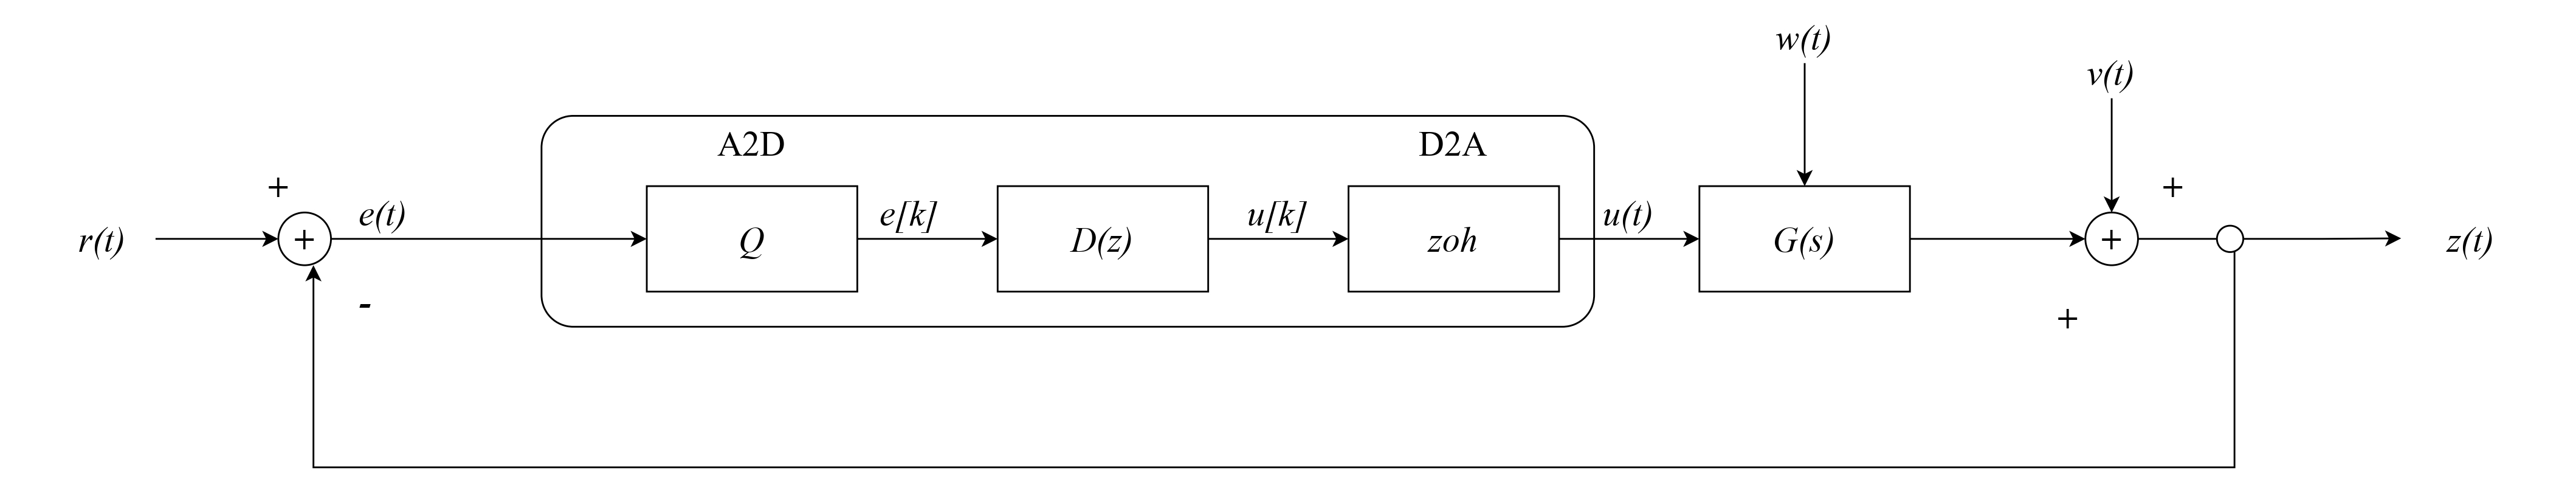

In [9]:
from IPython.display import Image
Image(filename="images/Comp_Monitoring_A2D_and_D2A.jpg")



- Linear discrete-time systems can be represented as

  $$
  x[k+1] = A_d\,x[k] + B_d\,u[k] + w[k]
  $$
  $$
  z[k] = C_d\,x[k] + D_d\,u[k] + v[k]
  $$

- The subscript “d” indicates discrete-time versions of $A, B, C, D$.

---



### 🧩 Time (Dynamic) Response of Discrete-Time Models


- Using induction from $x[k+1] = A_d x[k] + B_d u[k]$, the full solution is

  $$
  x[k] = A_d^k x[0] + \sum_{j=0}^{k-1} A_d^{k-1-j} B_d u[j]
  $$

- Since $z[k] = C_d x[k] + D_d u[k]$, then

  $$
  z[k] = C_d A_d^k x[0] + \sum_{j=0}^{k-1} C_d A_d^{k-1-j} B_d u[j] + D_d u[k]
  $$

- Comparing with continuous-time → $e^{A t}$ becomes $A_d^k$ and integrals become summations.

---



### 🧩 Converting Plant Dynamics to Discrete-Time


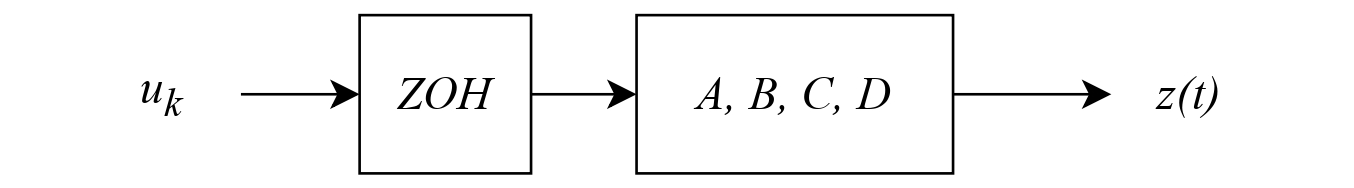

In [10]:
from IPython.display import Image
Image(filename="images/Plant_Dyn_to_discrete_time.jpg")



- Combine zero-order hold with the plant.

- Continuous-time model of the plant:

  $$
  \dot{x}(t) = A x(t) + B u(t)
  $$

- Evaluate sampled state:

  $$
  x((k+1)\Delta t) = \int_{0}^{(k+1)\Delta t} e^{A((k+1)\Delta t - \tau)} B u(\tau) d\tau
  $$

- → this leads to discrete-time mapping for \( x[k+1] \) under ZOH.

- ---


### 🧩 Converting Plant Dynamics to Discrete Time (2)

- We break up the integral into two pieces:

  $$
  x[k+1] = \int_{0}^{(k+1)\Delta t} e^{A((k+1)\Delta t - \tau)} B u(\tau) d\tau
  $$

  $$
  = \int_{0}^{k\Delta t} e^{A((k+1)\Delta t-\tau)} B u(\tau) d\tau + \int_{k\Delta t}^{(k+1)\Delta t} e^{A((k+1)\Delta t-\tau)} B u(\tau) d\tau
  $$

  $$
  = e^{A\Delta t} \int_{0}^{k\Delta t} e^{A(k\Delta t-\tau)} B u(\tau) d\tau + \int_{k\Delta t}^{(k+1)\Delta t} e^{A((k+1)\Delta t-\tau)} B u(\tau) d\tau
  $$

- The first integral becomes: $A_d\,x(k\Delta t)$  
- The second integral becomes: $B_d$ times $u(k\Delta t)$ after more work.

---

### 🧩 Converting Plant Dynamics to Discrete Time (3)

- In the remaining integral, assume $u(t)$ is constant from $k\Delta t$ to $(k+1)\Delta t$, and equal to $u(k\Delta t)$.

- Change variables: $\sigma = (k+1)\Delta t - \tau$  
  → $ \tau = (k+1)\Delta t - \sigma$ ; $d\tau = -d\sigma$

  $$
  x[k+1] = e^{A\Delta t} x(k\Delta t) + \int_{0}^{\Delta t} e^{A\sigma} B u(k\Delta t) d\sigma
  $$

  which yields:

  $$
  x[k+1] = A_d x[k] + \left[\int_{0}^{\Delta t} e^{A\sigma} B d\sigma\right] u[k]
  $$

  $$
  = A_d x[k] + B_d u[k]
  $$

---

### 🧩 Computing $A_d$, $C_d$, and $D_d$

- Final discrete-time representation from the continuous-time model:

  $$
  x[k+1] = A_d x[k] + B_d u[k]
  $$

  where

  $$
  A_d = e^{A\Delta t}, \qquad B_d = \int_{0}^{\Delta t} e^{A\sigma} B d\sigma
  $$

- Similarly,

  $$
  z[k] = C_d x[k] + D_d u[k]
  $$

  where  
  $C_d = C$ and $D_d = D$.

- So conversion for $C$ and $D$ is straightforward.  
- Conversion for $A$ uses matrix exponential $A_d = e^{A\Delta t}$.  
- In Octave: `Ad = expm(A*dt)`.
---

### 🧩 Computing \(B_d\)

- Now we focus on computing \(B_d\). Recall that:

  $$
  B_d = \int_{0}^{\Delta t} e^{A\sigma} B d\sigma
  $$

  $$
  = \int_{0}^{\Delta t} \left( I + A\sigma + \frac{A^2\sigma^2}{2!} + \frac{A^3\sigma^3}{3!} + \ldots \right) B d\sigma
  $$

  $$
  = \left( I\Delta t + A\frac{\Delta t^2}{2!} + A^2\frac{\Delta t^3}{3!} + \ldots \right) B
  $$

  $$
  = A^{-1}(e^{A\Delta t} - I)B = A^{-1}(A_d - I)B.
  $$

- If \(A\) is invertible, this method works nicely; otherwise, perform the integral manually.
- In Octave: `[Ad, Bd] = c2d(A, B, dT)`.


---

### 🧩 Summary

- Computer monitoring of physical systems requires A2D and D2A conversion.
- The system that is “seen” by the computer is a discrete-time system, and must be represented by a discrete-time state-space model:

  $$
  x[k+1] = A_d x[k] + B_d u[k] + w[k]
  $$
  $$
  z[k] = C_d x[k] + D_d u[k] + v[k]
  $$

- In general, the “A”, “B”, “C” and “D” matrices are **different** for discrete-time and continuous-time.
- You have learned how to convert continuous-time \(A,B,C,D\) to discrete-time \(A_d, B_d, C_d, D_d\).
- Next lesson → examples of converting continuous-time to discrete-time and simulating DT models.
---

### 🧩 Simulating Discrete-Time Systems

- When simulating discrete-time state-space models, we have at least two options:

  - Direct approach: write the simulation code ourselves.
  - Octave approach: use control package functions.
    - As with continuous-time models, `ss` creates a state-space object from $A, B, C, D$.
    - `lsim` simulates a state-space object for given input conditions and optional initial state.

- This lesson will show examples of both methods, applied to the NCP, NCV, and CT models previously introduced.

- First, we must convert continuous-time models into equivalent discrete-time models.

---

### 🧩 Converting the Nearly-Constant-Position Model

- We might want a discrete-time version of the continuous-time NCP model.

- Continuous-time form (2-D NCP example):

  $$
  \dot{x}(t) = \begin{bmatrix}0_{2\times2}\end{bmatrix} x(t) + I_2 w(t)
  $$
  $$
  z(t) = x(t) + v(t)
  $$

- In discrete-time, with sample period $\Delta t$:

  $$
  x[k+1] = e^{A\Delta t} x[k] + \left( \int_{0}^{\Delta t} e^{A\sigma} d\sigma \right) w[k]
  $$
  $$
  z[k] = x[k] + v[k]
  $$

---

### 🧩 Scaled Discrete-Time NCP Model

- To compute $A_d$: since $e^{A\Delta t} = I$, this is most easily confirmed via expansion of $e^{A t}$.

- To compute $B_d$: the simplified relation $B_d = A^{-1}(A_d - I)B$ **cannot** be used because $A$ is not invertible.

- Use the long-form integration method:

  $$
  \int_{0}^{\Delta t} I \, d\sigma = I\Delta t
  $$

- Discrete-time form of NCP model:

  $$
  x[k+1] = x[k] + \Delta t \, w[k]
  $$
  $$
  z[k] = x[k] + v[k]
  $$

- Note: $w[k]$ is often scaled differently in practice, so another common form is:

  $$
  x[k+1] = x[k] + w[k]
  $$
  $$
  z[k] = x[k] + v[k]
  $$
---